# Part 1: Market capitalization vs. Book Value of Equity

In [1]:
%pip install --upgrade pip setuptools wheel
%pip install "pandas>=3.0" numpy matplotlib
%pip install sqlalchemy psycopg2-binary
%pip install wrds --no-deps

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("walmart.csv")
data.head()

,costat,curcd,datafmt,indfmt,consol,sic,datadate,gvkey,conm,tic,fyear,at,ceq,ceql,gdwl,intan,aqc,csho,prcc_f
0,A,USD,STD,INDL,C,5080,2019-05-31,1004,AAR CORP,AIR,2018,1517.2,905.9,905.9,116.2,145.6,2.3,34.788,30.09
1,A,USD,STD,INDL,C,5080,2020-05-31,1004,AAR CORP,AIR,2019,2079.0,902.6,902.6,115.7,125.8,0.0,35.097,20.17
2,A,USD,STD,INDL,C,5080,2021-05-31,1004,AAR CORP,AIR,2020,1539.7,974.4,974.4,119.3,148.8,0.0,35.375,41.75
3,A,USD,STD,INDL,C,5080,2022-05-31,1004,AAR CORP,AIR,2021,1573.9,1034.5,1034.5,116.4,141.9,0.0,35.391,48.22
4,A,USD,STD,INDL,C,5080,2023-05-31,1004,AAR CORP,AIR,2022,1833.1,1099.1,1099.1,175.8,279.1,103.3,34.916,50.11


In [3]:
data["sic"] = data["sic"].astype(str)

industry = data[data["sic"].str[:2] == "53"].copy()
industry["market_cap"] = industry["prcc_f"] * industry["csho"] #Market Cap = Share Price * Sharesutstanding

latest_year = industry[industry["tic"] == "WMT"]["fyear"].max()
print(latest_year)
latest = industry[industry["fyear"] == latest_year].copy()
latest = latest.dropna(subset=["market_cap"])
latest["market_cap"].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
)

2025


count        16.000000
mean     102399.026839
std      247419.035962
min        1956.640000
1%         2157.816394
25%        6482.803425
50%       11283.911140
75%       48332.264850
99%      869729.810026
max      949426.660000
Name: market_cap, dtype: float64

In [4]:
walmart = latest[latest["tic"] == "WMT"]
wmt_market_cap = walmart["market_cap"].iloc[0] #iloc takes the first value of the market cap column
print("Walmart's Market Capitalisation:", wmt_market_cap)

Walmart's Market Capitalisation: 949426.66


In [5]:
#find the difference in market caps
#for every company in 'latest', company market cap - walmart market cap
# abs makes the result positive
latest["difference"] = abs(
    latest["market_cap"] - wmt_market_cap
)
not_walmart=latest[latest["tic"] != "WMT"] #removes walmart
sorted_companies=not_walmart.sort_values("difference") #sorts company market cap difference in ascending order
peers = sorted_companies.head(5) #keeps first 5 companies (closest peers)
print(peers[["conm", "tic", "market_cap", "difference"]])


                             conm    tic     market_cap     difference
27032       COSTCO WHOLESALE CORP   COST  418114.326840  531312.333160
66761  WAL MART DE MEXICO S A B D  WMMVY   53868.692592  895557.967408
87903               DOLLARAMA INC  DLMAF   50045.955000  899380.705000
1825                  TARGET CORP    TGT   47761.034800  901665.625200
1948          DOLLAR GENERAL CORP     DG   31586.441460  917840.218540


['WMT', 'COST', 'WMMVY', 'DLMAF', 'TGT', 'DG']
[2021, 2022, 2023, 2024, 2025]
tic     COST     DG  DLMAF    TGT  WMMVY    WMT
fyear                                          
2021   0.087  0.131 -0.003  0.123  0.139  0.216
2022   0.089  0.108  0.001  0.142  0.168  0.198
2023   0.103  0.233  0.014  0.209  0.160  0.189
2024   0.060  0.474  0.031  0.233  0.243  0.116
2025   0.070  0.269  0.029  0.338  0.243  0.105


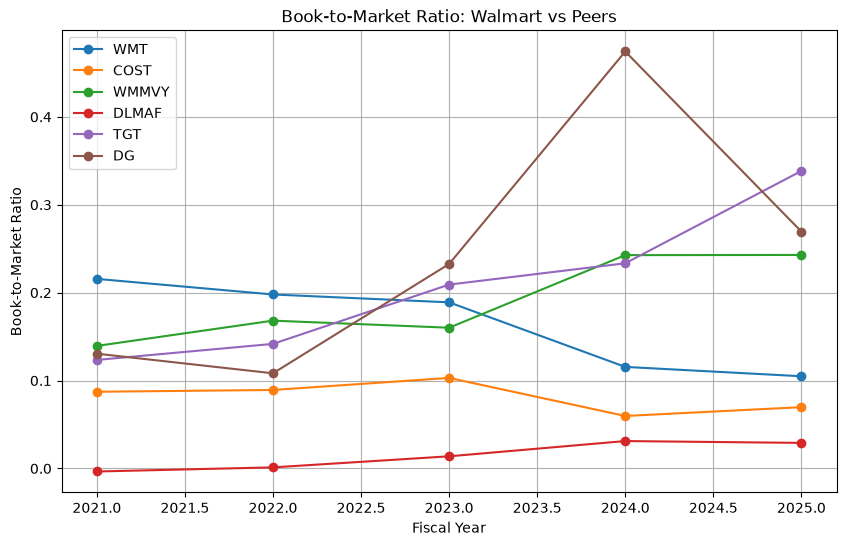

In [6]:
#calculate book-to-market=book value of equity(common equity)/market value of equity(market cap)
industry["book_to_market"] = (
    industry["ceq"] / industry["market_cap"]
)
companies = ["WMT"] + peers["tic"].tolist()
print(companies)
comparison = industry[industry["tic"].isin(companies)].copy()
years = list(range(int(latest_year) - 4, int(latest_year) + 1))

print(years)
comparison = comparison[comparison["fyear"].isin(years)].copy()

btm_table = comparison.pivot_table(
    index="fyear",
    columns="tic",
    values="book_to_market"
)

print(btm_table.round(3))

plt.figure(figsize=(10, 6))

for company in companies:
    company_data = comparison[comparison["tic"] == company]
    company_data = company_data.sort_values("fyear")

    plt.plot(
        company_data["fyear"],
        company_data["book_to_market"],
        marker="o",
        label=company
    )

plt.xlabel("Fiscal Year")
plt.ylabel("Book-to-Market Ratio")
plt.title("Book-to-Market Ratio: Walmart vs Peers")
plt.legend()
plt.grid()

plt.show()


In [7]:
btm_change = btm_table.iloc[-1] - btm_table.iloc[0]

print(btm_change.round(3)) #2025 B/M - 2021 B/M

comparison = industry[industry["tic"].isin(companies)].copy()

years = list(range(int(latest_year) - 4, int(latest_year) + 1))

comparison = comparison[
    comparison["fyear"].isin(years)
].copy()

btm_table = comparison.pivot_table(
    index="fyear",
    columns="tic",
    values="book_to_market"
)

print(btm_table.round(3))

btm_change = btm_table.iloc[-1] - btm_table.iloc[0]

print(btm_change.round(3))

tic
COST    -0.018
DG       0.139
DLMAF    0.033
TGT      0.215
WMMVY    0.103
WMT     -0.111
dtype: float64
tic     COST     DG  DLMAF    TGT  WMMVY    WMT
fyear                                          
2021   0.087  0.131 -0.003  0.123  0.139  0.216
2022   0.089  0.108  0.001  0.142  0.168  0.198
2023   0.103  0.233  0.014  0.209  0.160  0.189
2024   0.060  0.474  0.031  0.233  0.243  0.116
2025   0.070  0.269  0.029  0.338  0.243  0.105
tic
COST    -0.018
DG       0.139
DLMAF    0.033
TGT      0.215
WMMVY    0.103
WMT     -0.111
dtype: float64


### Book-to-Market Comparison

Walmart's book-to-market ratio fell from **0.216 in 2021** to **0.105 in 2025**, representing a decrease of **0.111** over the five-year period.

This contrasts with most of its selected peers, whose book-to-market ratios increased over the same period. **Costco** was the only other peer to experience a decline, although its decrease was much smaller at **0.018**.

By 2025, Walmart's book-to-market ratio of **0.105** was lower than those of **Dollar General, Target, and Wal-Mart de México**, but higher than **Costco and Dollarama**.

# Part 2 Profitability

In [8]:
import pandas as pd

# Read data
df = pd.read_csv("financial_data.csv")

# Calculate ratios
df["ROA"] = (df["ni"] / df["at"]) * 100
df["ROE"] = (df["ni"] / df["seq"]) * 100

# Show results
print(df[["tic", "fyear", "ROA", "ROE"]])

      tic  fyear        ROA        ROE
0    COST   2021   8.448066  28.507174
1    COST   2022   9.107627  28.311210
2    COST   2023   9.119634  25.109745
3    COST   2024  10.549756  31.172513
4    COST   2025  10.504676  27.770539
5      DG   2021   9.113071  38.314234
6      DG   2022   8.307116  43.595965
7      DG   2023   5.394519  24.614679
8      DG   2024   3.614373  15.178007
9      DG   2025   4.884137  17.766891
10    TGT   2021  12.908141  54.151399
11    TGT   2022   5.212337  24.750712
12    TGT   2023   7.475251  30.807028
13    TGT   2024   7.081653  27.894450
14    TGT   2025   6.227937  22.919889
15  WMMVY   2021  11.191492  23.745206
16  WMMVY   2022  11.693700  24.188564
17  WMMVY   2023  11.817750  25.912743
18  WMMVY   2024  10.898592  23.114238
19  WMMVY   2025  10.073378  21.177831
20    WMT   2021   5.584007  16.423432
21    WMT   2022   4.802691  15.229552
22    WMT   2023   6.145428  18.496083
23    WMT   2024   7.451797  21.355191
24    WMT   2025   7.6907

      tic  fyear        ROA        ROE
0    COST   2021   8.448066  28.507174
1    COST   2022   9.107627  28.311210
2    COST   2023   9.119634  25.109745
3    COST   2024  10.549756  31.172513
4    COST   2025  10.504676  27.770539
5      DG   2021   9.113071  38.314234
6      DG   2022   8.307116  43.595965
7      DG   2023   5.394519  24.614679
8      DG   2024   3.614373  15.178007
9      DG   2025   4.884137  17.766891
10    TGT   2021  12.908141  54.151399
11    TGT   2022   5.212337  24.750712
12    TGT   2023   7.475251  30.807028
13    TGT   2024   7.081653  27.894450
14    TGT   2025   6.227937  22.919889
15  WMMVY   2021  11.191492  23.745206
16  WMMVY   2022  11.693700  24.188564
17  WMMVY   2023  11.817750  25.912743
18  WMMVY   2024  10.898592  23.114238
19  WMMVY   2025  10.073378  21.177831
20    WMT   2021   5.584007  16.423432
21    WMT   2022   4.802691  15.229552
22    WMT   2023   6.145428  18.496083
23    WMT   2024   7.451797  21.355191
24    WMT   2025   7.6907

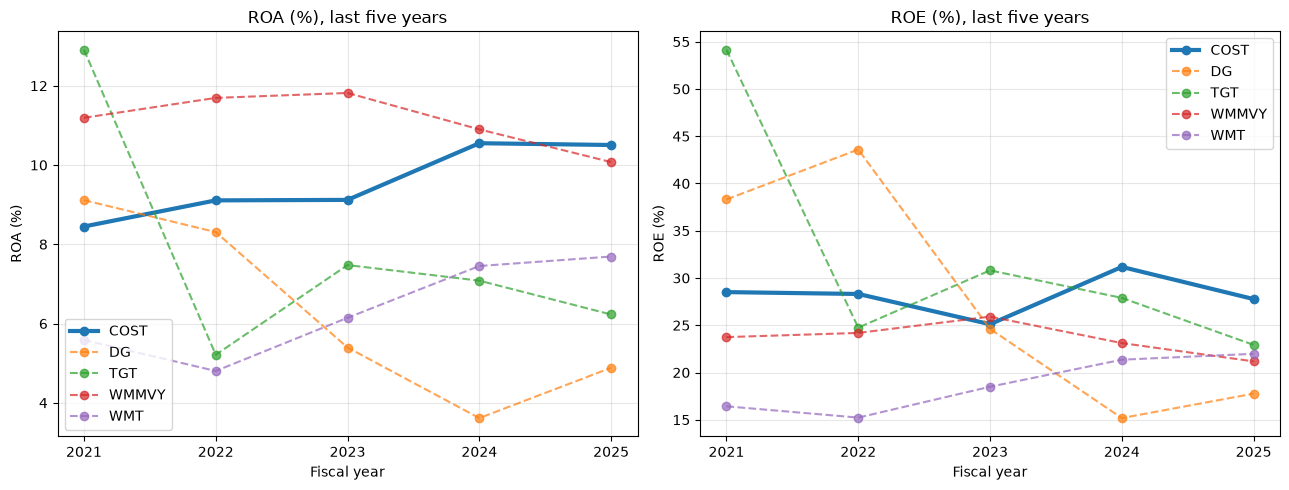

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("financial_data.csv")
df["ROA"] = (df["ni"] / df["at"]) * 100
df["ROE"] = (df["ni"] / df["seq"]) * 100

ASSIGNED = "COST"  # your assigned company

# Keep the last five years
df5 = df[df["fyear"] > df["fyear"].max() - 5]
print(df5[["tic", "fyear", "ROA", "ROE"]].sort_values(["tic", "fyear"]))

# Plot ROA and ROE: assigned company vs peers
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["ROA", "ROE"]):
    for tic, g in df5.groupby("tic"):
        g = g.sort_values("fyear")
        if tic == ASSIGNED:
            ax.plot(g["fyear"], g[metric], marker="o", linewidth=3, label=tic)
        else:
            ax.plot(g["fyear"], g[metric], marker="o", linestyle="--", alpha=0.7, label=tic)
    ax.set_title(f"{metric} (%), last five years")
    ax.set_xlabel("Fiscal year")
    ax.set_ylabel(f"{metric} (%)")
    ax.set_xticks(sorted(df5["fyear"].unique()))
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roa_roe.png", dpi=200)
plt.show()

In [10]:
import pandas as pd

# Read data
df = pd.read_csv("financial_data2.csv")

# Calculate ratios
df["ROA"] = (df["ni"] / df["at"]) * 100
df["ROE"] = (df["ni"] / df["seq"]) * 100

# Show results
print(df[["tic", "fyear", "ROA", "ROE"]])

      tic  fyear        ROA        ROE
0    COST   2021   8.448066  28.507174
1    COST   2022   9.107627  28.311210
2    COST   2023   9.119634  25.109745
3    COST   2024  10.549756  31.172513
4    COST   2025  10.504676  27.770539
5      DG   2021   9.113071  38.314234
6      DG   2022   8.307116  43.595965
7      DG   2023   5.394519  24.614679
8      DG   2024   3.614373  15.178007
9      DG   2025   4.884137  17.766891
10    TGT   2021  12.908141  54.151399
11    TGT   2022   5.212337  24.750712
12    TGT   2023   7.475251  30.807028
13    TGT   2024   7.081653  27.894450
14    TGT   2025   6.227937  22.919889
15  WMMVY   2021  11.191492  23.745206
16  WMMVY   2022  11.693700  24.188564
17  WMMVY   2023  11.817750  25.912743
18  WMMVY   2024  10.898592  23.114238
19  WMMVY   2025  10.073378  21.177831
20    WMT   2021   5.584007  16.423432
21    WMT   2022   4.802691  15.229552
22    WMT   2023   6.145428  18.496083
23    WMT   2024   7.451797  21.355191
24    WMT   2025   7.6907

      tic  fyear        ROA        ROE
0    COST   2021   8.448066  28.507174
1    COST   2022   9.107627  28.311210
2    COST   2023   9.119634  25.109745
3    COST   2024  10.549756  31.172513
4    COST   2025  10.504676  27.770539
5      DG   2021   9.113071  38.314234
6      DG   2022   8.307116  43.595965
7      DG   2023   5.394519  24.614679
8      DG   2024   3.614373  15.178007
9      DG   2025   4.884137  17.766891
10    TGT   2021  12.908141  54.151399
11    TGT   2022   5.212337  24.750712
12    TGT   2023   7.475251  30.807028
13    TGT   2024   7.081653  27.894450
14    TGT   2025   6.227937  22.919889
15  WMMVY   2021  11.191492  23.745206
16  WMMVY   2022  11.693700  24.188564
17  WMMVY   2023  11.817750  25.912743
18  WMMVY   2024  10.898592  23.114238
19  WMMVY   2025  10.073378  21.177831
20    WMT   2021   5.584007  16.423432
21    WMT   2022   4.802691  15.229552
22    WMT   2023   6.145428  18.496083
23    WMT   2024   7.451797  21.355191
24    WMT   2025   7.6907

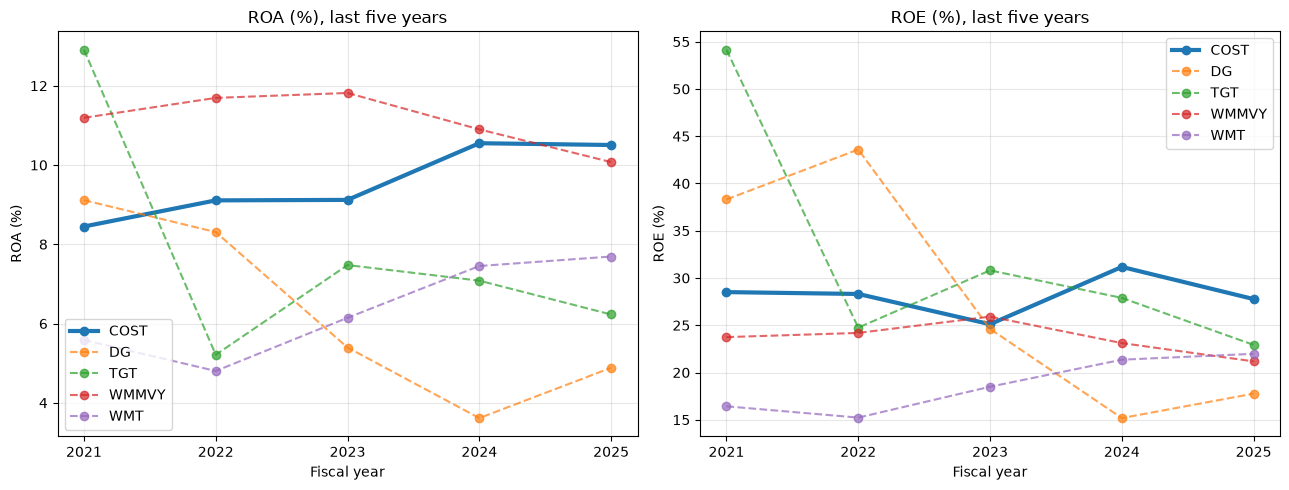

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("financial_data2.csv")
df["ROA"] = (df["ni"] / df["at"]) * 100
df["ROE"] = (df["ni"] / df["seq"]) * 100

ASSIGNED = "COST"  # your assigned company

# Keep the last five years
df5 = df[df["fyear"] > df["fyear"].max() - 5]
print(df5[["tic", "fyear", "ROA", "ROE"]].sort_values(["tic", "fyear"]))

# Plot ROA and ROE: assigned company vs peers
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["ROA", "ROE"]):
    for tic, g in df5.groupby("tic"):
        g = g.sort_values("fyear")
        if tic == ASSIGNED:
            ax.plot(g["fyear"], g[metric], marker="o", linewidth=3, label=tic)
        else:
            ax.plot(g["fyear"], g[metric], marker="o", linestyle="--", alpha=0.7, label=tic)
    ax.set_title(f"{metric} (%), last five years")
    ax.set_xlabel("Fiscal year")
    ax.set_ylabel(f"{metric} (%)")
    ax.set_xticks(sorted(df5["fyear"].unique()))
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roa_roe.png", dpi=200)
plt.show()

Walmart’s profitability was below its peers for most of the period but has largely caught up. In 2021 its ROA (5.6%) and ROE (16.4%) were well below the peer averages (10.4% and 36.2%). Since 2022, Walmart’s ROA and ROE have risen steadily, while the peer averages have fallen, so by 2025 the gaps are almost closed (ROA 7.7% vs 7.9%, ROE 22.0% vs 22.4%).

The main difference is direction. Walmart improved, while Dollar General and Target saw sharp declines after 2021-2022 and WMMVY slipped from 2023. Costco was the only peer whose returns stayed strong, and it remains ahead of Walmart on ROA (10.5% vs 7.7%). Walmart’s low ROA reflects its very large asset base, but its net income has grown faster than its assets since 2022.

# Part 3: Stock-Market Performance

In [12]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [14]:
crsp = pd.read_csv("crsp.csv")
ff = pd.read_csv("ff.csv")

crsp.head()

,PERMNO,HdrCUSIP,Ticker,PERMCO,DlyCalDt,DlyPrc,DlyCap,DlyRet
0,16678,50104410,KR,21068,2020-01-02,28.66,22944823.42,-0.011383
1,16678,50104410,KR,21068,2020-01-03,28.70,22976846.90,0.001396
2,16678,50104410,KR,21068,2020-01-06,28.80,23056905.60,0.003484
3,16678,50104410,KR,21068,2020-01-07,28.59,22888782.33,-0.007292
4,16678,50104410,KR,21068,2020-01-08,28.42,22752682.54,-0.005946


In [15]:
ff.head()

,date,mktrf,smb,hml,rf
0,2021-01-04,-0.0141,0.0020,0.0057,0.0
1,2021-01-05,0.0086,0.0122,0.0050,0.0
2,2021-01-06,0.0079,0.0214,0.0394,0.0
3,2021-01-07,0.0176,0.0032,-0.0081,0.0
4,2021-01-08,0.0051,-0.0075,-0.0138,0.0


In [16]:
# turn the date columns into proper dates
crsp["date"] = pd.to_datetime(crsp["DlyCalDt"])
ff["date"] = pd.to_datetime(ff["date"])

# quick check of which companies we have
crsp["Ticker"].unique()

<ArrowStringArray>
['KR', 'TGT', 'WMT', 'COST']
Length: 4, dtype: str

In [17]:
# one column of returns per company
rets = crsp.pivot(index="date", columns="Ticker", values="DlyRet")

# put the returns and factors side by side, matched on date
data = pd.merge(rets, ff, on="date")
data = data.set_index("date").dropna()

data.head()

,COST,KR,TGT,WMT,mktrf,smb,hml,rf
date,,,,,,,,
2021-01-04,0.008944,0.011650,0.006231,0.016511,-0.0141,0.0020,0.0057,0.0
2021-01-05,-0.011601,-0.007158,0.015425,-0.005323,0.0086,0.0122,0.0050,0.0
2021-01-06,-0.015223,0.009718,0.047403,0.006244,0.0079,0.0214,0.0394,0.0
2021-01-07,-0.005675,-0.012108,0.011539,-0.000068,0.0176,0.0032,-0.0081,0.0
2021-01-08,0.005490,-0.005971,0.013082,-0.000136,0.0051,-0.0075,-0.0138,0.0


In [18]:
# check the sample period
print(data.index.min(), data.index.max(), len(data))

2021-01-04 00:00:00 2025-12-31 00:00:00 1255


In [19]:
tickers = ["WMT", "COST", "TGT", "KR"]

# Market return = market excess return + risk-free rate
data["MKT"] = data["mktrf"] + data["rf"]
all_rets = data[tickers + ["MKT"]]

summary = pd.DataFrame({
    "Mean daily return": all_rets.mean(),
    "Annualised return": all_rets.mean() * 252,
    "Annualised volatility": all_rets.std() * np.sqrt(252),
    "Total 5-year return": (1 + all_rets).prod() - 1,
})
print(summary.round(4))

      Mean daily return  Annualised return  Annualised volatility  \
WMT              0.0008             0.2044                 0.2088   
COST             0.0008             0.2028                 0.2251   
TGT             -0.0001            -0.0271                 0.3514   
KR               0.0008             0.1935                 0.2704   
MKT              0.0006             0.1407                 0.1773   

      Total 5-year return  
WMT                1.4814  
COST               1.4178  
TGT               -0.3631  
KR                 1.1878  
MKT                0.8633  


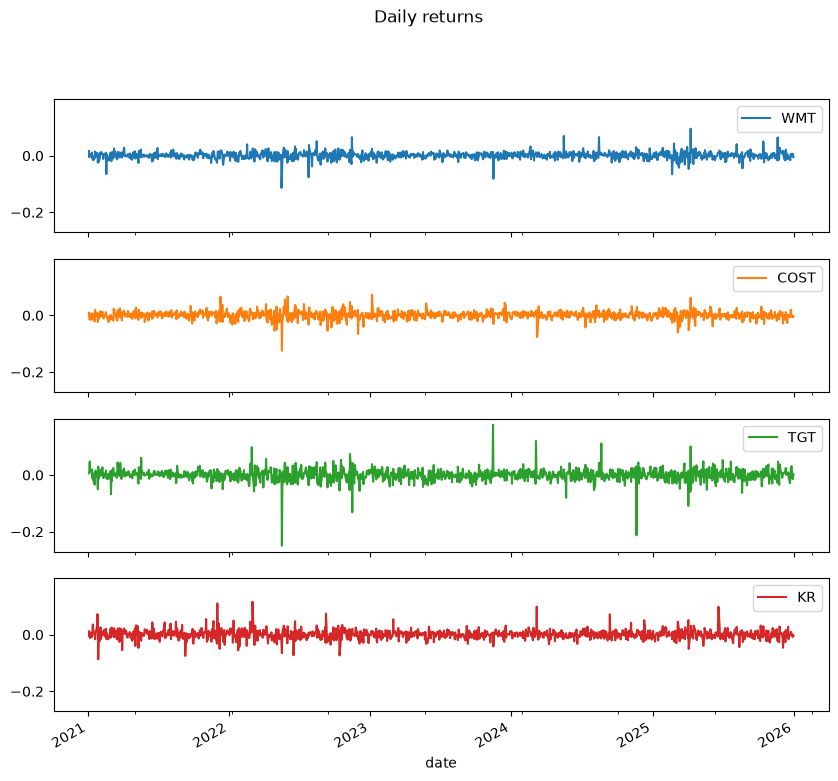

In [20]:
data[tickers].plot(subplots=True, figsize=(10, 9), sharey=True, title="Daily returns")
plt.savefig("fig1_daily_returns.png")
plt.show()

         WMT    COST     TGT      KR     MKT
date                                        
2021  0.0197  0.5181  0.3292  0.4540  0.2384
2022 -0.0047 -0.1906 -0.3427  0.0044 -0.1996
2023  0.1289  0.4897 -0.0136  0.0499  0.2690
2024  0.7398  0.3962 -0.0216  0.3690  0.2489
2025  0.2449 -0.0540 -0.2447  0.0423  0.1859


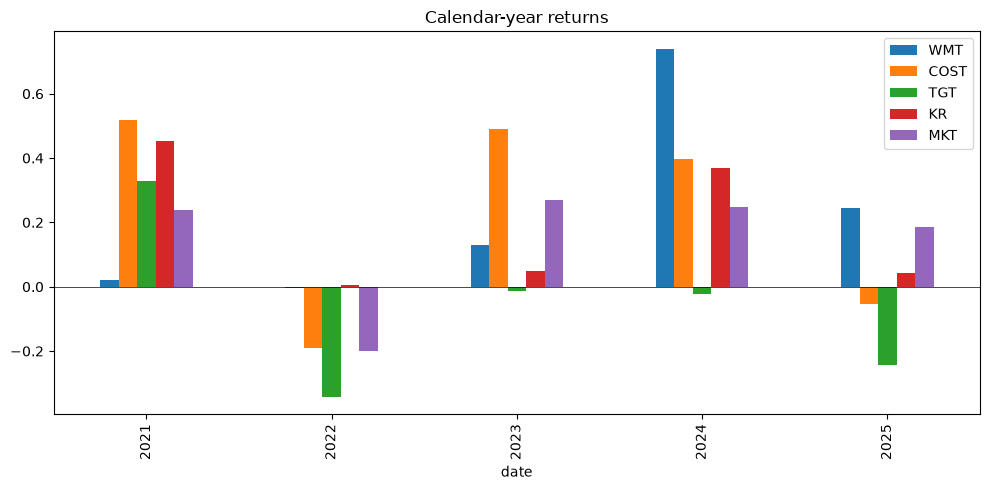

In [21]:
annual = (1 + all_rets).groupby(all_rets.index.year).prod() - 1
print(annual.round(4))

annual.plot(kind="bar", figsize=(10, 5), title="Calendar-year returns")
plt.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("fig2_annual_returns.png", dpi=200)
plt.show()

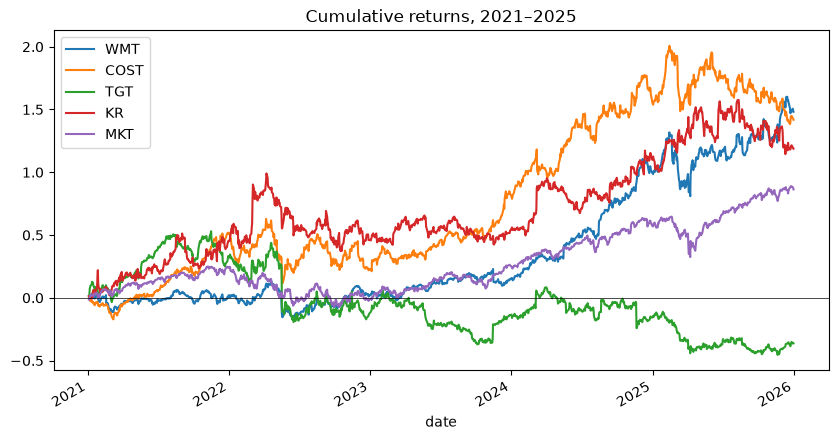

In [22]:
cum = (1 + all_rets).cumprod() - 1

cum.plot(figsize=(10, 5), title="Cumulative returns, 2021–2025")
plt.axhline(0, color="black", linewidth=0.5)
plt.savefig("fig3_cumulative_returns.png")
plt.show()

In [23]:
capm_results = {}

for t in tickers:
    y = data[t] - data["rf"]               # excess stock return
    X = sm.add_constant(data[["mktrf"]])   # market excess return + intercept
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    capm_results[t] = {
        "Alpha (daily)": model.params["const"],
        "Alpha (annualised)": model.params["const"] * 252,
        "Alpha t-stat": model.tvalues["const"],
        "Alpha p-value": model.pvalues["const"],
        "Beta": model.params["mktrf"],
        "R-squared": model.rsquared,
    }

capm_table = pd.DataFrame(capm_results).T
print(capm_table.round(4))

      Alpha (daily)  Alpha (annualised)  Alpha t-stat  Alpha p-value    Beta  \
WMT          0.0005              0.1260        1.4622         0.1437  0.4229   
COST         0.0004              0.0927        1.0939         0.2740  0.7164   
TGT         -0.0006             -0.1629       -1.2147         0.2245  0.9547   
KR           0.0006              0.1465        1.2953         0.1952  0.1323   

      R-squared  
WMT      0.1289  
COST     0.3181  
TGT      0.2318  
KR       0.0075  


In [24]:
ff3_results = {}

for t in tickers:
    y = data[t] - data["rf"]
    X = sm.add_constant(data[["mktrf", "smb", "hml"]])
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    ff3_results[t] = {
        "Alpha (annualised)": model.params["const"] * 252,
        "Alpha t-stat": model.tvalues["const"],
        "Alpha p-value": model.pvalues["const"],
        "Beta (MKT)": model.params["mktrf"],
        "SMB": model.params["smb"],
        "HML": model.params["hml"],
        "R-squared": model.rsquared,
    }

ff3_table = pd.DataFrame(ff3_results).T
print(ff3_table.round(4))

      Alpha (annualised)  Alpha t-stat  Alpha p-value  Beta (MKT)     SMB  \
WMT               0.1025        1.1993         0.2304      0.4906 -0.2260   
COST              0.0867        1.0567         0.2907      0.7376 -0.3234   
TGT              -0.1604       -1.1841         0.2364      0.9429  0.3391   
KR                0.1044        0.9370         0.3488      0.2493 -0.0994   

         HML  R-squared  
WMT   0.0578     0.1441  
COST -0.1790     0.3562  
TGT   0.2238     0.2515  
KR    0.3270     0.0379  


      Raw return (ann.)  CAPM alpha (ann.)  CAPM t-stat  FF3 alpha (ann.)  \
WMT              0.2044             0.1260       1.4622            0.1025   
COST             0.2028             0.0927       1.0939            0.0867   
TGT             -0.0271            -0.1629      -1.2147           -0.1604   
KR               0.1935             0.1465       1.2953            0.1044   

      FF3 t-stat  
WMT       1.1993  
COST      1.0567  
TGT      -1.1841  
KR        0.9370  


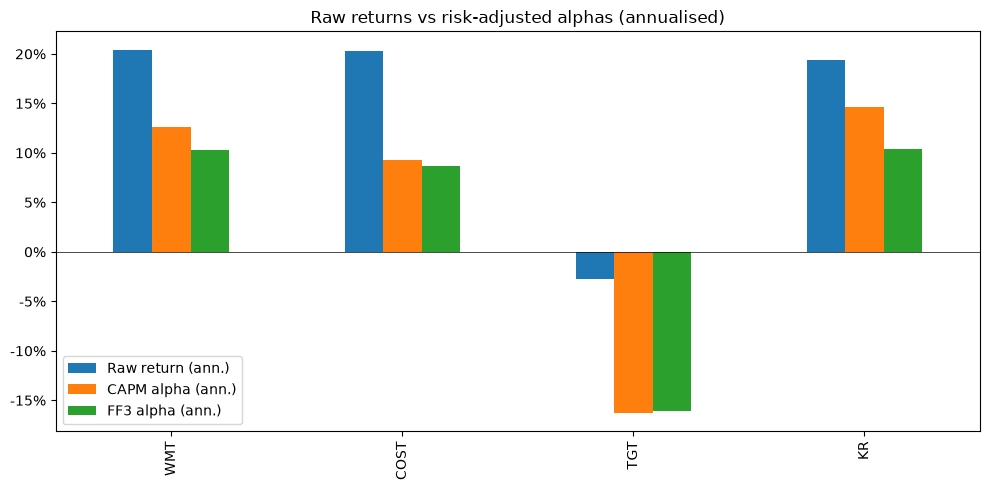

In [25]:
comparison = pd.DataFrame({
    "Raw return (ann.)": summary.loc[tickers, "Annualised return"],
    "CAPM alpha (ann.)": capm_table["Alpha (annualised)"],
    "CAPM t-stat": capm_table["Alpha t-stat"],
    "FF3 alpha (ann.)": ff3_table["Alpha (annualised)"],
    "FF3 t-stat": ff3_table["Alpha t-stat"],
})
print(comparison.round(4))
comparison.round(4).to_csv("comparison_table.csv")

comparison[["Raw return (ann.)", "CAPM alpha (ann.)", "FF3 alpha (ann.)"]].plot(
    kind="bar", figsize=(10, 5), title="Raw returns vs risk-adjusted alphas (annualised)")
plt.axhline(0, color="black", linewidth=0.5)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("fig4_raw_vs_alpha.png", dpi=200)
plt.show()

# Part 4: Earnings Announcements

    rel       ret     abret       car       date       vol
0   -20 -0.002613 -0.009413 -0.009413 2025-10-23  11408241
1   -19 -0.006457 -0.014557 -0.023970 2025-10-24  10317959
2   -18 -0.016012 -0.028012 -0.051983 2025-10-27  16375860
3   -17 -0.012444 -0.014444 -0.066426 2025-10-28  13322994
4   -16 -0.006882 -0.006182 -0.072608 2025-10-29  11986407
5   -15 -0.002245  0.008555 -0.064053 2025-10-30  14065077
6   -14 -0.010271 -0.014471 -0.078524 2025-10-31  20237018
7   -13  0.004052  0.002652 -0.075872 2025-11-03  14811687
8   -12  0.006694  0.019094 -0.056778 2025-11-04  12636350
9   -11 -0.007822 -0.012222 -0.069001 2025-11-05  13356821
10  -10  0.002070  0.013970 -0.055031 2025-11-06  14866025
11   -9  0.008950  0.007450 -0.047581 2025-11-07  17248716
12   -8 -0.001657 -0.016957 -0.064538 2025-11-10  14507603
13   -7  0.009959  0.007959 -0.056579 2025-11-11  13182144
14   -6  0.000000 -0.000500 -0.057079 2025-11-12  12084407
15   -5 -0.008701  0.008999 -0.048080 2025-11-13  180885

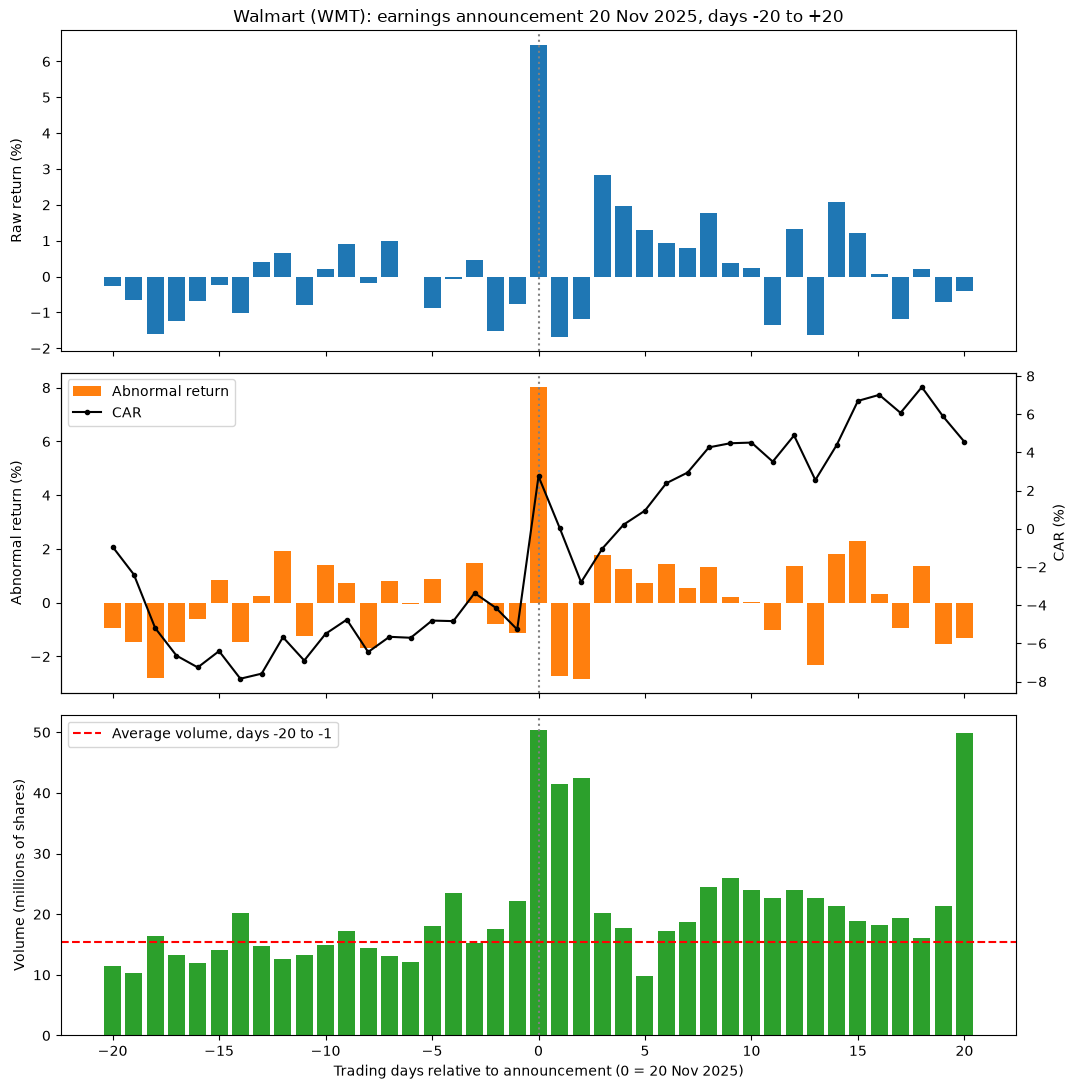

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

EVENT_DATE  = pd.Timestamp("2025-11-20")
EVENT_FILE  = "wmt_event.csv"
VOLUME_FILE = "wmt_volume.csv"



# WRDS Event Study Data
ev = pd.read_csv(EVENT_FILE) # reads the file
ev = ev[["evttime", "ret_m", "abret_m", "car_m"]] #keeps only these columns
ev = ev.rename(columns={"evttime": "rel", "ret_m": "ret", "abret_m": "abret", "car_m": "car"}) #rename columns

# WRDS Compustat Data
px = pd.read_csv(VOLUME_FILE) #read the volume file
px.columns = [c.lower() for c in px.columns] #lowers the column names

#Alternatively
#(new_names = []
#for c in px.columns:
#   new_names.append(c.lower())

px = px.rename(columns={"dlycaldt": "date", "dlyvol": "vol"}) #rename colums

px["date"] = pd.to_datetime(px["date"]) #turns text into date format
px = px.sort_values("date").reset_index(drop=True) #puts the rows in date order, oldest first. (might not be in order, renumbers the rows 0, 1, 2, 3 and so on. Sorting shuffles the row numbers along with the rows, so you’d see something like 5, 2, 9. To make this clean, reset the index to 0, 1, 2.), drop duplicates

#We do this to match volume data with the event study data. The event study data is in relative days, so we need to create a relative day column in the volume data as well.
pos0 = px.index[px["date"] == EVENT_DATE][0] #find the position of the event date in the index. This is a list, so we take the first element with [0], this a boolean True or False so only one date should remain which is our event date.

#print(px.head()) to verify postion vs relative position
px["rel"] = px.index - pos0 #creates a new column called rel, which is the index minus the position of the event date. This gives us a relative day count, with 0 being the event date, negative numbers before, and positive numbers after.

base = px[(px["rel"] >= -20) & (px["rel"] <= -1)]["vol"].mean()  #calculates the average volume for the 20 days before the event date, which we will use as a baseline for comparison in the volume chart.

df = ev.merge(px[["rel", "date", "vol"]], on="rel", how="left") #matches the two dataframes on the relative day column, keeping all rows from the event study data and adding the volume data where available.
print(df) #check if worked

#Creates the graphs and charts
fig, ax = plt.subplots(3, 1, figsize=(11, 11), sharex=True)

ax[0].bar(df["rel"], df["ret"] * 100, color="tab:blue")
ax[0].set_ylabel("Raw return (%)")
ax[0].set_title("Walmart (WMT): earnings announcement 20 Nov 2025, days -20 to +20")

ax[1].bar(df["rel"], df["abret"] * 100, color="tab:orange", label="Abnormal return")
ax[1].set_ylabel("Abnormal return (%)")
ax2 = ax[1].twinx()
ax2.plot(df["rel"], df["car"] * 100, color="black", marker="o", ms=3, label="CAR")
ax2.set_ylabel("CAR (%)")
h1, l1 = ax[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax[1].legend(h1 + h2, l1 + l2, loc="upper left")

ax[2].bar(df["rel"], df["vol"] / 1e6, color="tab:green")
ax[2].axhline(base / 1e6, color="red", ls="--", label="Average volume, days -20 to -1")
ax[2].set_ylabel("Volume (millions of shares)")
ax[2].set_xlabel("Trading days relative to announcement (0 = 20 Nov 2025)")
ax[2].legend()

for a in ax:
    a.axvline(0, color="grey", ls=":")

plt.tight_layout()
plt.savefig("walmart_event_study.png", dpi=150)
plt.show()

